In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import uproot
import glob
import os

In [2]:
def as_array(inpath,folder, varname, cut, nchunks):
    if nchunks is not None:
        files = glob.glob(os.path.join(os.path.abspath(inpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inpath), folder, "*.root:events" )

    try: 
        # awkward array instead of numpy -> allows variable length elements
        #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
        arr = uproot.concatenate( path, expressions=varname, cut=cut)
    except:
        branches = get_list_of_branches(folder)
        print( f"Branches found in files at path {folder}:" )
        for br in branches:
            print('  ', br)
        raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )

    # Return awkward array as a flattened ndarray
    return arr

In [3]:
input = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_noPV_ntracks_cut"
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV"]
decay_list = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"]
cuts = "Rec_PV_ntracks>1"
df_dict={}
for decay in decay_list:
    df_dict[decay] = as_array(inpath=input,folder=decay, varname=vars, cut=cuts, nchunks=1)

In [4]:
df_dict["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]


<Array [{...}, {...}, {...}, ..., {...}, {...}] type='90179 * {Rec_vtx_thru...'>

In [5]:
dict_for_df_perdecay = {}
for sample in decay_list:
    dict_for_df={}
    for variable in vars:
         dict_for_df[variable] = ak.to_numpy(ak.ravel(df_dict[sample][variable]))
    dict_for_df_perdecay[sample] = dict_for_df

In [6]:
dict_for_df_perdecay["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]

{'Rec_vtx_thrustCosTheta': array([-0.99131006, -0.99625355, -0.98703724, ...,  0.9832437 ,
        -0.98992366, -0.9965716 ], dtype=float32),
 'Rec_vtx_in_hemisEmin': array([0, 0, 0, ..., 1, 0, 0], dtype=int32),
 'Rec_vtx_thrustCosTheta_d2PV': array([ 0.        , -0.99656636, -0.99240375, ...,  0.        ,
        -0.9997992 , -0.9984683 ], dtype=float32),
 'Rec_vtx_in_hemisEmin_d2PV': array([-1,  0,  0, ..., -1,  0,  0], dtype=int32),
 'Rec_vtx_isPV': array([1, 0, 0, ..., 1, 0, 0], dtype=int32)}

In [7]:
samples_dfs={}
for sample in decay_list:
    # Create a DataFrame from the dictionary
    df = pd.DataFrame(dict_for_df_perdecay[sample])
    samples_dfs[sample] = df[df["Rec_vtx_isPV"]==0]
    


In [8]:
decay_list_plot = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91"]#, "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"]

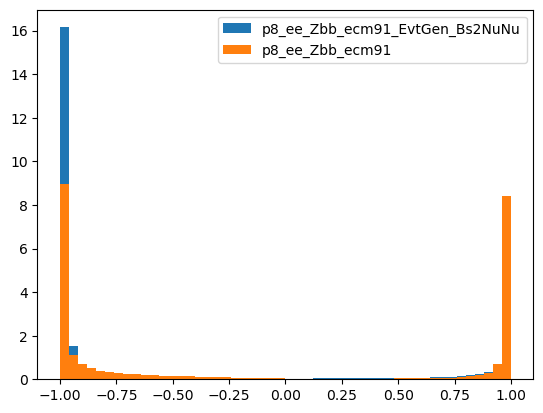

In [11]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_thrustCosTheta"],bins=50,label=sample,density=True)
plt.legend()

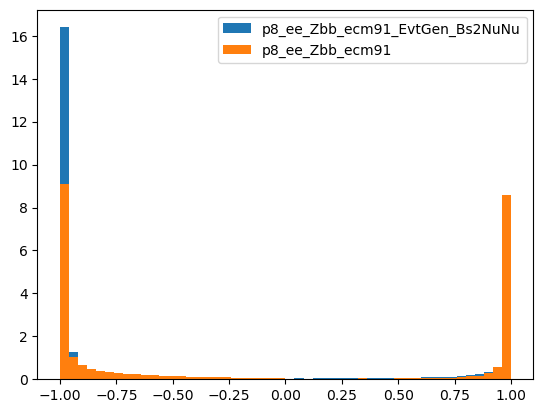

In [10]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_thrustCosTheta_d2PV"],bins=50,density=True,label=sample)
plt.legend()

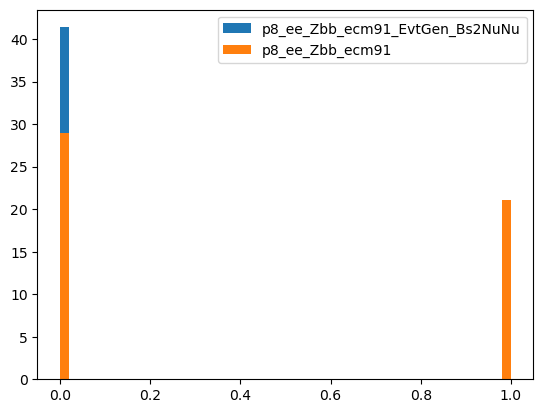

In [12]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin"],bins=50,density=True,label=sample)
plt.legend()

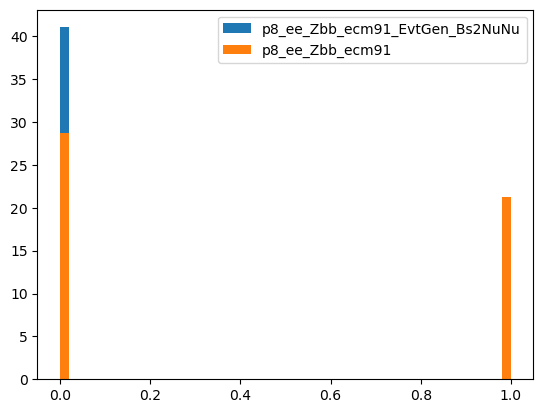

In [13]:
for sample in decay_list_plot:
    plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin_d2PV"],bins=50,density=True,label=sample)
plt.legend()

In [14]:
for sample in decay_list_plot:
    df = samples_dfs[sample]
    print(len(df))
    df_misagreement = df[df["Rec_vtx_in_hemisEmin_d2PV"]!=df["Rec_vtx_in_hemisEmin"]]
    #plt.hist(samples_dfs[sample]["Rec_vtx_in_hemisEmin_d2PV"],bins=50,density=True,label=sample)
    df_misagreement
    print(len(df_misagreement))
    print(len(df_misagreement)/len(df))

203193
2696
0.013268173608342808
152693
2154
0.014106737047539834


In [15]:
df_misagreement

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV
43,0.788128,1,-0.434076,0,0
82,-0.962893,0,0.849001,1,0
120,0.114779,1,-0.207699,0,0
333,0.991613,1,-0.992359,0,0
669,-0.385187,0,0.391073,1,0
...,...,...,...,...,...
200589,-0.998810,0,0.998686,1,0
200887,-0.999188,0,0.867964,1,0
201187,-0.714580,0,0.715953,1,0
201300,0.999138,1,-0.974186,0,0


In [17]:
df_misagreement[np.sign(df_misagreement["Rec_vtx_thrustCosTheta"]) == np.sign(df_misagreement["Rec_vtx_thrustCosTheta_d2PV"])]

,Rec_vtx_thrustCosTheta,Rec_vtx_in_hemisEmin,Rec_vtx_thrustCosTheta_d2PV,Rec_vtx_in_hemisEmin_d2PV,Rec_vtx_isPV


In [ ]:
# Compare arrays element-wise
comparison = np.equal(arr1, arr2)

# Return False if any pair doesn't match
return comparison.all()

In [49]:
## Now look at whole df where a row == an event
def as_np(inpath,folder, varname, cut, nchunks):
    if nchunks is not None:
        files = glob.glob(os.path.join(os.path.abspath(inpath), folder, "*.root"))[:nchunks]
        path = [ f"{f}:events" for f in files ]
    else:
        path = os.path.join( os.path.abspath(inpath), folder, "*.root:events" )


    # awkward array instead of numpy -> allows variable length elements
    #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
    a = uproot.concatenate( path, expressions=varname, cut=cut, library="np" )

    # Return awkward array as a flattened ndarray
    return a


In [52]:
input = "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_noPV_ntracks_cut"
vars = ["Rec_vtx_thrustCosTheta", "Rec_vtx_in_hemisEmin","Rec_vtx_thrustCosTheta_d2PV", "Rec_vtx_in_hemisEmin_d2PV","Rec_vtx_isPV"]
decay_list = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu","p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91", "p8_ee_Zss_ecm91", "p8_ee_Zud_ecm91"]
cuts = "Rec_PV_ntracks>1"
df_dict={}
for decay in decay_list:
    df_dict[decay] = pd.DataFrame(as_np(inpath=input,folder=decay, varname=vars, cut=cuts, nchunks=1))

In [171]:
filtered_dict={}
for decay in decay_list:
    ddd = df_dict[decay]
    arry=[]
    for i in range(len(ddd)):
        comparison = np.equal(ddd["Rec_vtx_in_hemisEmin"][i][1:], ddd["Rec_vtx_in_hemisEmin_d2PV"][i][1:])
        arry.append(comparison.all())
    # Return False if any pair doesn't match
    
    count = arry.count(False)
    ddd["vtx_assignment_agreement"] = arry
    print(f"Frac to remove {count/len(arry)}")
    print(len(arry))
    print(len(ddd))
    print(len(ddd[ddd["vtx_assignment_agreement"]==True]))
    filtered_dict[decay] = ddd[ddd["vtx_assignment_agreement"]==True]
          
        

Frac to remove 0.029219663114472327
90179
90179
87544
Frac to remove 0.04299506984387839
48680
48680
46587
Frac to remove 0.05695404328305504
39646
39646
37388
Frac to remove 0.02624641299022467
42863
42863
41738
Frac to remove 0.019833717319443053
19966
19966
19570
